### How are in-demand skills trending for Data Analysts?

#### Methodology

        1. Aggregate skill count monthly
        2. Re-analyze based on percentage of total jobs
        3. Plot the monthly skill demand.

In [3]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [8]:
df_da_swe = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'Sweden')].copy()

In [47]:
df_da_swe['job_posted_month_no'] = df_da_swe['job_posted_date'].dt.month

In [48]:
df_da_swe_explode = df_da_swe.explode('job_skills')

In [ ]:
df_da_swe_pivot = df_da_swe_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_da_swe_pivot.loc['Total']  = df_da_swe_pivot.sum()
df_da_swe_pivot = df_da_swe_pivot[df_da_swe_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_swe_pivot = df_da_swe_pivot.drop('Total')

df_da_swe_pivot

job_skills,sql,python,tableau,power bi,r,looker,excel,gcp,azure,bigquery,...,confluence,c++,airflow,redshift,mysql,postgresql,spss,sql server,unix,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,20,16,2,10,8,3,4,5,4,5,...,0,0,0,1,0,0,0,0,0,0
2,17,13,7,4,9,4,4,4,3,1,...,0,0,0,0,0,0,0,0,0,1
3,8,5,3,4,1,2,3,3,1,4,...,0,0,0,0,0,0,0,0,0,0
4,8,5,3,2,4,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,11,7,5,3,3,4,5,4,1,3,...,0,0,0,0,0,0,0,0,0,0
6,19,11,11,10,6,8,3,1,5,3,...,0,0,0,0,0,0,0,0,0,0
7,13,12,7,1,6,6,1,3,0,3,...,0,0,0,0,0,0,0,0,0,0
8,27,15,17,13,7,4,8,3,4,3,...,0,1,1,0,1,1,1,1,0,0
9,11,5,5,2,2,3,1,1,3,2,...,0,0,0,0,0,0,0,0,0,0


In [50]:
# df_da_swe_pivot.plot(kind='line')

In [51]:
df_da_swe_totals = df_da_swe.groupby('job_posted_month_no').size()

In [52]:
df_da_swe_percent = df_da_swe_pivot.div(df_da_swe_totals/100, axis=0)

df_da_swe_percent

job_skills,sql,python,tableau,power bi,r,looker,excel,gcp,azure,bigquery,...,confluence,c++,airflow,redshift,mysql,postgresql,spss,sql server,unix,windows
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,60.606061,48.484848,6.060606,30.303030,24.242424,9.090909,12.121212,15.151515,12.121212,15.151515,...,0.000000,0.000000,0.000000,3.030303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,80.952381,61.904762,33.333333,19.047619,42.857143,19.047619,19.047619,19.047619,14.285714,4.761905,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.761905
3,57.142857,35.714286,21.428571,28.571429,7.142857,14.285714,21.428571,21.428571,7.142857,28.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,88.888889,55.555556,33.333333,22.222222,44.444444,33.333333,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,73.333333,46.666667,33.333333,20.000000,20.000000,26.666667,33.333333,26.666667,6.666667,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,67.857143,39.285714,39.285714,35.714286,21.428571,28.571429,10.714286,3.571429,17.857143,10.714286,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,72.222222,66.666667,38.888889,5.555556,33.333333,33.333333,5.555556,16.666667,0.000000,16.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,90.000000,50.000000,56.666667,43.333333,23.333333,13.333333,26.666667,10.000000,13.333333,10.000000,...,0.000000,3.333333,3.333333,0.000000,3.333333,3.333333,3.333333,3.333333,0.000000,0.000000
9,84.615385,38.461538,38.461538,15.384615,15.384615,23.076923,7.692308,7.692308,23.076923,15.384615,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_da_swe_percent = df_da_swe_percent.reset_index()
df_da_swe_percent['job_posted_month'] = df_da_swe_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format= '%m').strftime('%b'))
df_da_swe_percent = df_da_swe_percent.set_index('job_posted_month')
df_da_swe_percent = df_da_swe_percent.drop(columns = 'job_posted_month_no')

df_da_swe_percent

job_skills,sql,python,tableau,power bi,r,looker,excel,gcp,azure,bigquery,...,confluence,c++,airflow,redshift,mysql,postgresql,spss,sql server,unix,windows
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,60.606061,48.484848,6.060606,30.303030,24.242424,9.090909,12.121212,15.151515,12.121212,15.151515,...,0.000000,0.000000,0.000000,3.030303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,80.952381,61.904762,33.333333,19.047619,42.857143,19.047619,19.047619,19.047619,14.285714,4.761905,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.761905
Mar,57.142857,35.714286,21.428571,28.571429,7.142857,14.285714,21.428571,21.428571,7.142857,28.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,88.888889,55.555556,33.333333,22.222222,44.444444,33.333333,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,73.333333,46.666667,33.333333,20.000000,20.000000,26.666667,33.333333,26.666667,6.666667,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,67.857143,39.285714,39.285714,35.714286,21.428571,28.571429,10.714286,3.571429,17.857143,10.714286,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,72.222222,66.666667,38.888889,5.555556,33.333333,33.333333,5.555556,16.666667,0.000000,16.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,90.000000,50.000000,56.666667,43.333333,23.333333,13.333333,26.666667,10.000000,13.333333,10.000000,...,0.000000,3.333333,3.333333,0.000000,3.333333,3.333333,3.333333,3.333333,0.000000,0.000000
Sep,84.615385,38.461538,38.461538,15.384615,15.384615,23.076923,7.692308,7.692308,23.076923,15.384615,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


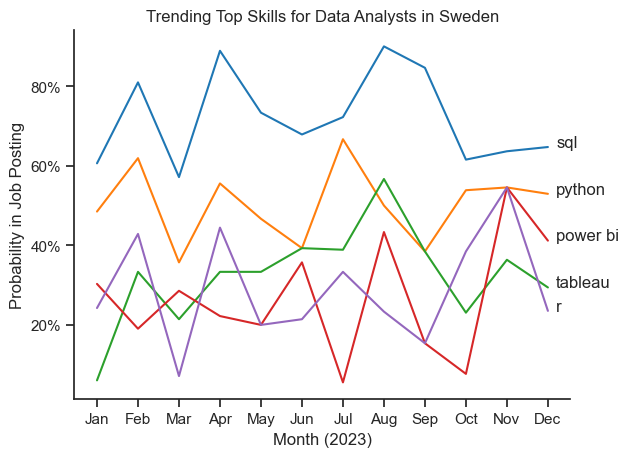

In [70]:
df_plot = df_da_swe_percent.iloc[:,:5]

sns.set_theme(style = 'ticks')
sns.lineplot(data=df_plot, dashes=False, palette = 'tab10')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in Sweden')
plt.ylabel('Probability in Job Posting')
plt.xlabel('Month (2023)')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i])